In [45]:
! gdown 17Pv4BbJB2d8WoqGYNCQ0rvY9i2j6BRJB

Downloading...
From: https://drive.google.com/uc?id=17Pv4BbJB2d8WoqGYNCQ0rvY9i2j6BRJB
To: /content/Вар_47_Б24-215_Новиков_Лаба2_студент-3.xlsx
100% 299k/299k [00:00<00:00, 82.3MB/s]


In [46]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# ЧАСТЬ 1: Экстракт подготовки данных из Блока 1
# =====================================================================

features = [
    'Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.',
    'Количество членов семьи', 'Количество лет образования',
    'Доля от дохода семьи которая тратится на продовольствие, %',
    'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $',
    'Охват беспроводной связи в сообществе, %',
    'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек',
    'Волатильность потребительских цен в сообществе'
]

hidden_states = ['Оценка благополучия', 'Оценка социальной поддержки']
target = 'Ощущаемое счастье'

# Корректная функция очистки текстовых меток с исправлением опечаток
def clean_labels(series):
    return (series.astype(str)
            .str.strip().str.lower()
            .str.replace('strugglng', 'struggling')
            .str.replace('just ok', 'just_ok')
            .str.replace('doing well', 'doing_well'))

print("ПОДГОТОВКА ДАННЫХ...")

# Загрузка файлов
train_df = pd.read_excel('/content/Вар_47_Б24-215_Новиков_Лаба2_студент-3.xlsx')
val_df = pd.read_excel('/content/Вар_47_Б24-215_Новиков_Лаба2_студент-3.xlsx')

# Исключаем строки, где целевой признак неизвестен или отсутствует
train_df = train_df[(train_df[target].notnull()) & (train_df[target].astype(str).str.lower() != 'неизвестно')].copy()
val_df = val_df[(val_df[target].notnull()) & (val_df[target].astype(str).str.lower() != 'неизвестно')].copy()

# Применяем очистку текстовых классов из Блока 1
train_df[target] = clean_labels(train_df[target])
val_df[target] = clean_labels(val_df[target])

# Заполнение пропусков средними (избавляет от необходимости жесткого удаления строк через dropna)
for col in features + hidden_states:
    if train_df[col].isnull().sum() > 0:
        train_df[col] = train_df[col].fillna(train_df[col].mean())
    if val_df[col].isnull().sum() > 0:
        val_df[col] = val_df[col].fillna(train_df[col].mean()) # Валидацию заполняем средними из Train

# =====================================================================
# ЧАСТЬ 2: Логика диагностики Блока 2
# =====================================================================
print("\nЗАПУСК ДИАГНОСТИКИ ДАННЫХ...\n")

# ПРОВЕРКА 1: БАЛАНС КЛАССОВ (TARGET SHIFT)
print("=== ПРОВЕРКА 1: Распределение классов Счастья ===")
train_dist = train_df[target].value_counts(normalize=True) * 100
val_dist = val_df[target].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Train %': train_dist, 'Val %': val_dist}).fillna(0)
print(dist_df.round(1))
print("ВЫВОД 1: Если проценты сильно отличаются, модель на валидации будет ошибаться.\n")

# ПРОВЕРКА 2: СВЯЗЬ ПРИЗНАКОВ И СКРЫТЫХ СОСТОЯНИЙ (R-squared)
print("=== ПРОВЕРКА 2: Адекватность Этапа 1 (R-squared) ===")
X_train_diag = train_df[features]

for hs in hidden_states:
    y_train_diag = train_df[hs]
    model = Ridge()
    model.fit(X_train_diag, y_train_diag)
    preds = model.predict(X_train_diag)
    r2 = r2_score(y_train_diag, preds)
    print(f"R^2 для '{hs}': {r2:.4f}")
print("ВЫВОД 2: Если R^2 < 0.2, базовые признаки слабо объясняют скрытые состояния.\n")

# ПРОВЕРКА 3: МАСШТАБЫ ПРИЗНАКОВ (COVARIATE SHIFT)
print("=== ПРОВЕРКА 3: Средние значения признаков (Train vs Val) ===")
for col in features[:4]:
    mean_train = train_df[col].mean()
    mean_val = val_df[col].mean()
    print(f"{col}:")
    print(f"  Train: {mean_train:.2f} | Val: {mean_val:.2f}")
print("\nВЫВОД 3: Если средние значения сильно расходятся, данные валидации могут требовать масштабирования.")

ПОДГОТОВКА ДАННЫХ...

ЗАПУСК ДИАГНОСТИКИ ДАННЫХ...

=== ПРОВЕРКА 1: Распределение классов Счастья ===
                   Train %  Val %
Ощущаемое счастье                
suffering             14.3   14.3
coping                13.9   13.9
doing_well            13.8   13.8
struggling            13.8   13.8
just_ok               12.7   12.7
depressed             10.5   10.5
thriving               8.8    8.8
hopeless               7.6    7.6
blooming               3.9    3.9
prospering             0.7    0.7
ВЫВОД 1: Если проценты сильно отличаются, модель на валидации будет ошибаться.

=== ПРОВЕРКА 2: Адекватность Этапа 1 (R-squared) ===
R^2 для 'Оценка благополучия': 0.0264
R^2 для 'Оценка социальной поддержки': 0.9029
ВЫВОД 2: Если R^2 < 0.2, базовые признаки слабо объясняют скрытые состояния.

=== ПРОВЕРКА 3: Средние значения признаков (Train vs Val) ===
Среднегодовой доход, тыс. $:
  Train: 136.78 | Val: 136.78
Объем потребленного алкоголя в год, л.:
  Train: 7.21 | Val: 7.21
Количест

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

features = [
    'Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.',
    'Количество членов семьи', 'Количество лет образования',
    'Доля от дохода семьи которая тратится на продовольствие, %',
    'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $',
    'Охват беспроводной связи в сообществе, %',
    'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек',
    'Волатильность потребительских цен в сообществе'
]
hidden_states = ['Оценка благополучия', 'Оценка социальной поддержки'] # Возьмем пару для проверки
target = 'Ощущаемое счастье'

def clean_target_labels(series):
    return series.astype(str).str.strip().str.lower()

print("ЗАПУСК ДИАГНОСТИКИ ДАННЫХ...\n")

# Загрузка
train_df = pd.read_excel('/content/Вар_47_Б24-215_Новиков_Лаба2_студент-3.xlsx').dropna(subset=[target])
val_df = pd.read_excel('/content/Вар_47_Б24-215_Новиков_Лаба2_студент-3.xlsx').dropna(subset=[target])

train_df[target] = clean_target_labels(train_df[target])
val_df[target] = clean_target_labels(val_df[target])

# ========================================================
# ПРОВЕРКА 1: БАЛАНС КЛАССОВ (TARGET SHIFT)
# ========================================================
print("=== ПРОВЕРКА 1: Распределение классов Счастья ===")
train_dist = train_df[target].value_counts(normalize=True) * 100
val_dist = val_df[target].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Train %': train_dist, 'Val %': val_dist}).fillna(0)
print(dist_df.round(1))
print("ВЫВОД 1: Если проценты сильно отличаются (например, класс есть в Train, но его 0% в Val), модель обречена ошибаться.\n")

# ========================================================
# ПРОВЕРКА 2: МОЖЕМ ЛИ МЫ ВООБЩЕ ПРЕДСКАЗАТЬ СКРЫТЫЕ СОСТОЯНИЯ?
# ========================================================
print("=== ПРОВЕРКА 2: Адекватность Этапа 1 (R-squared) ===")
# Очистим пропуски для теста
train_hs_df = train_df.dropna(subset=hidden_states + features)

imputer = SimpleImputer(strategy='median')
X_train_diag = imputer.fit_transform(train_hs_df[features])

for hs in hidden_states:
    y_train_diag = train_hs_df[hs]
    model = Ridge()
    model.fit(X_train_diag, y_train_diag)
    preds = model.predict(X_train_diag)
    r2 = r2_score(y_train_diag, preds)
    print(f"R^2 для '{hs}': {r2:.4f}")

print("ВЫВОД 2: Если R^2 < 0.2, это значит, что Признаки НЕ влияют на Скрытые состояния. Модель 1-го уровня передает классификатору просто шум.\n")

# ========================================================
# ПРОВЕРКА 3: МАСШТАБЫ ПРИЗНАКОВ (COVARIATE SHIFT)
# ========================================================
print("=== ПРОВЕРКА 3: Средние значения признаков (Train vs Val) ===")
for col in features[:4]: # Проверим первые 4 признака
    mean_train = train_df[col].mean()
    mean_val = val_df[col].mean()
    print(f"{col}:")
    print(f"  Train: {mean_train:.2f} | Val: {mean_val:.2f}")

print("\nВЫВОД 3: Если средние отличаются в разы или на порядки, признаки в val_data в другой размерности!")

ЗАПУСК ДИАГНОСТИКИ ДАННЫХ...

=== ПРОВЕРКА 1: Распределение классов Счастья ===
                   Train %  Val %
Ощущаемое счастье                
неизвестно            24.0   24.0
suffering             10.8   10.8
coping                10.6   10.6
doing well            10.5   10.5
strugglng             10.5   10.5
just ok                9.6    9.6
depressed              8.0    8.0
thriving               6.7    6.7
hopeless               5.8    5.8
blooming               3.0    3.0
prospering             0.5    0.5
ВЫВОД 1: Если проценты сильно отличаются (например, класс есть в Train, но его 0% в Val), модель обречена ошибаться.

=== ПРОВЕРКА 2: Адекватность Этапа 1 (R-squared) ===
R^2 для 'Оценка благополучия': 0.0264
R^2 для 'Оценка социальной поддержки': 0.9029
ВЫВОД 2: Если R^2 < 0.2, это значит, что Признаки НЕ влияют на Скрытые состояния. Модель 1-го уровня передает классификатору просто шум.

=== ПРОВЕРКА 3: Средние значения признаков (Train vs Val) ===
Среднегодовой доход, ты

1. Отрисовка корреляционной матрицы...


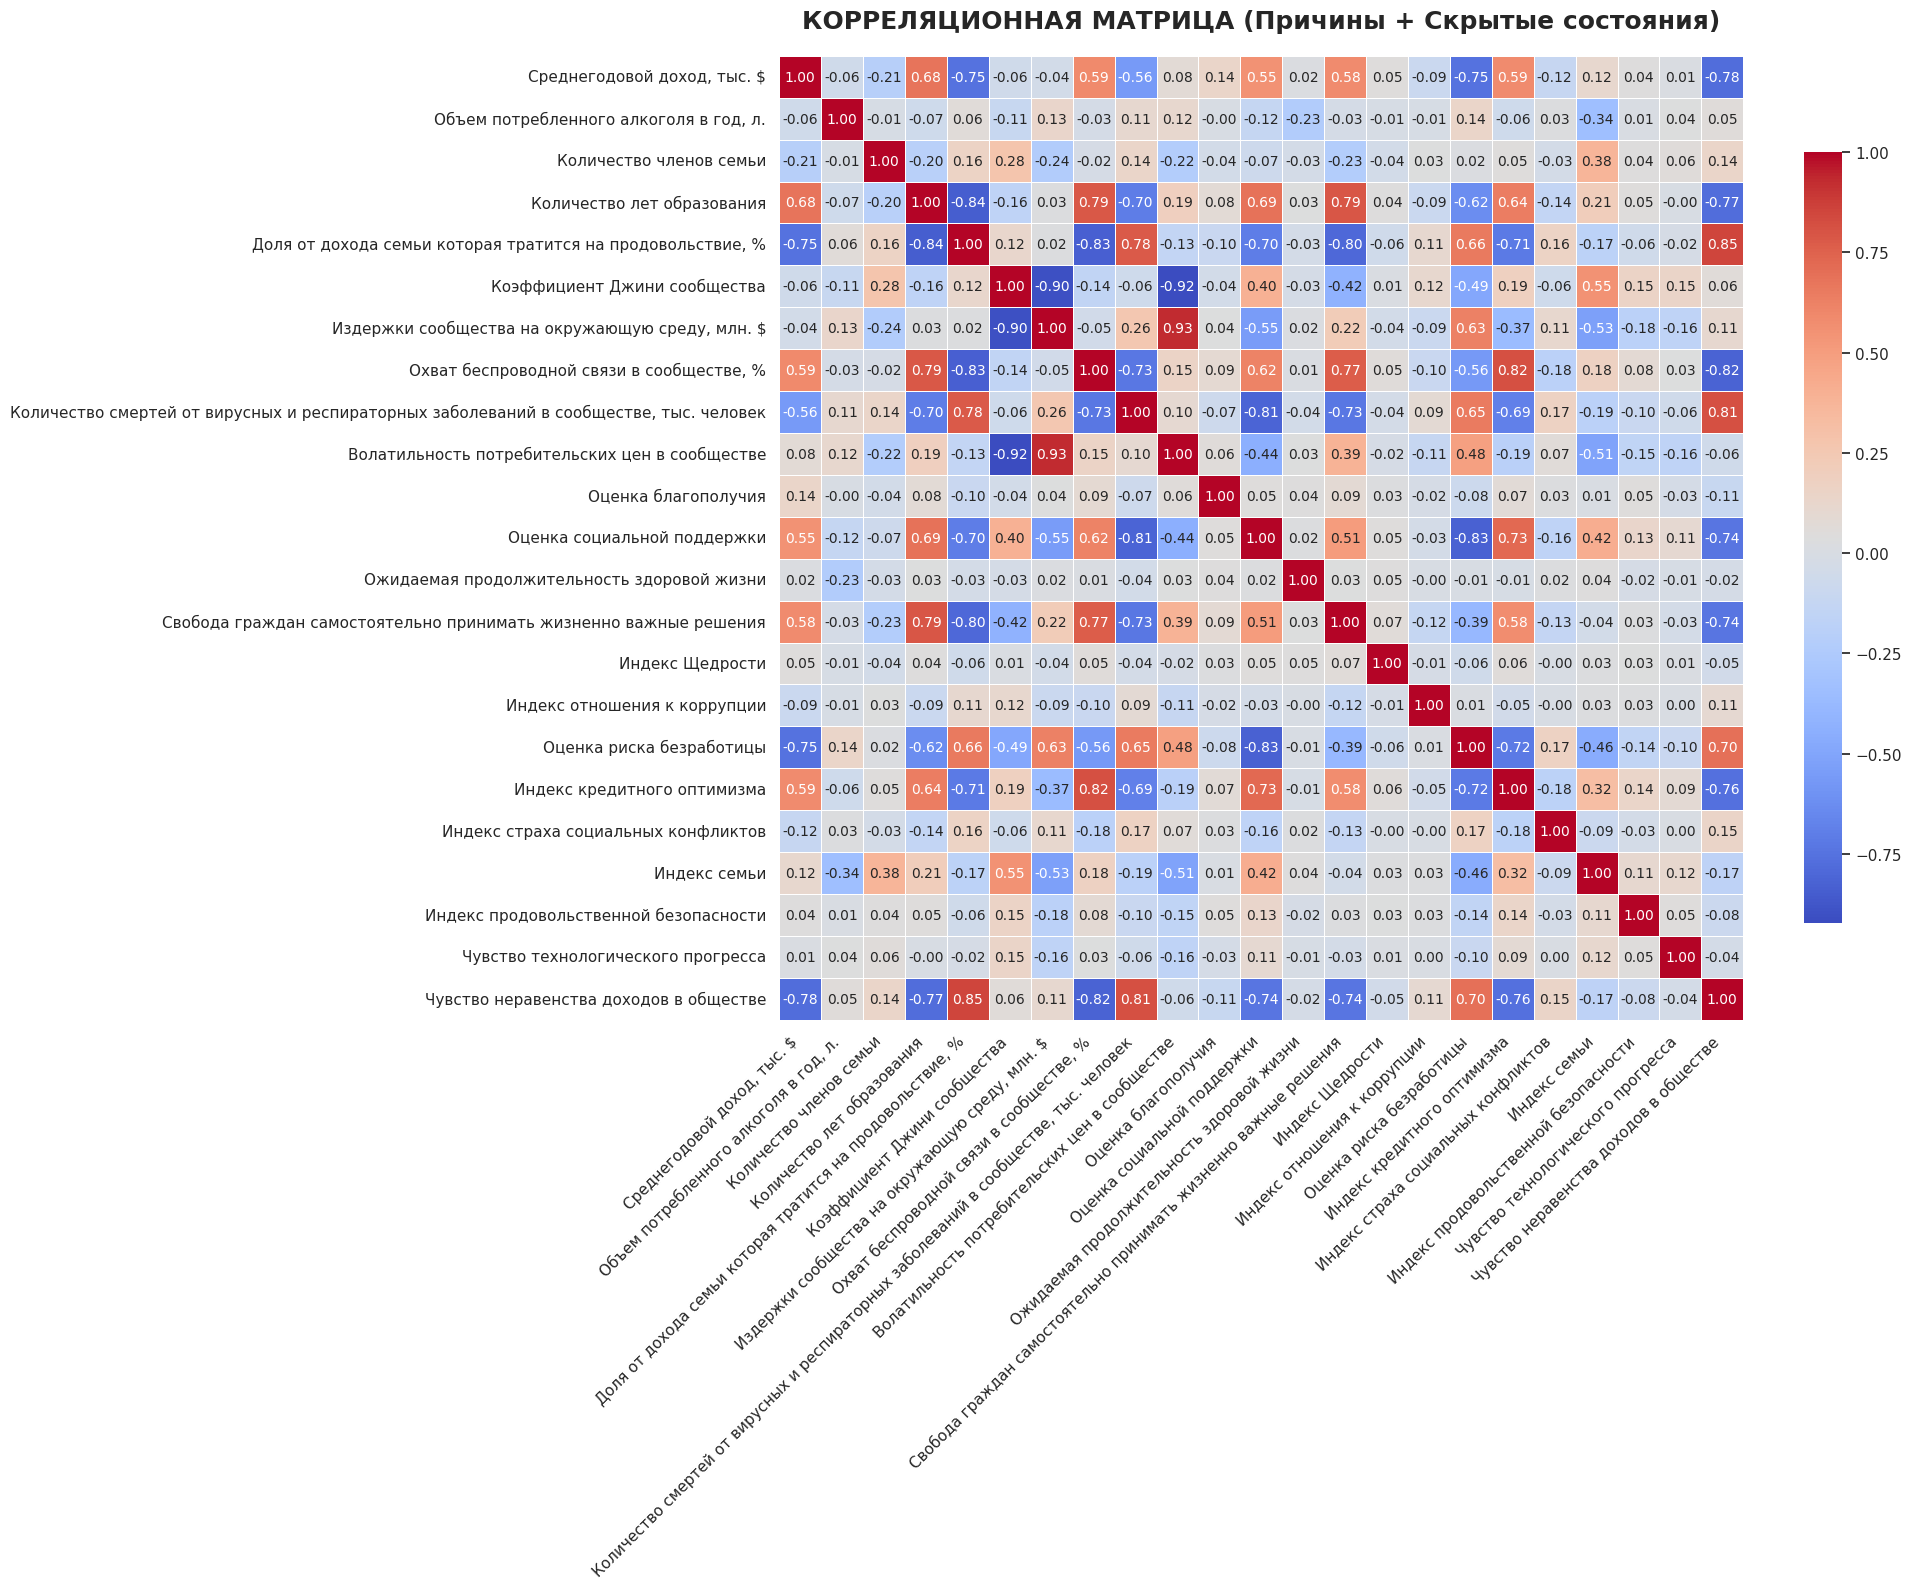

2. Отрисовка плотностей распределения базовых признаков по классам Счастья...


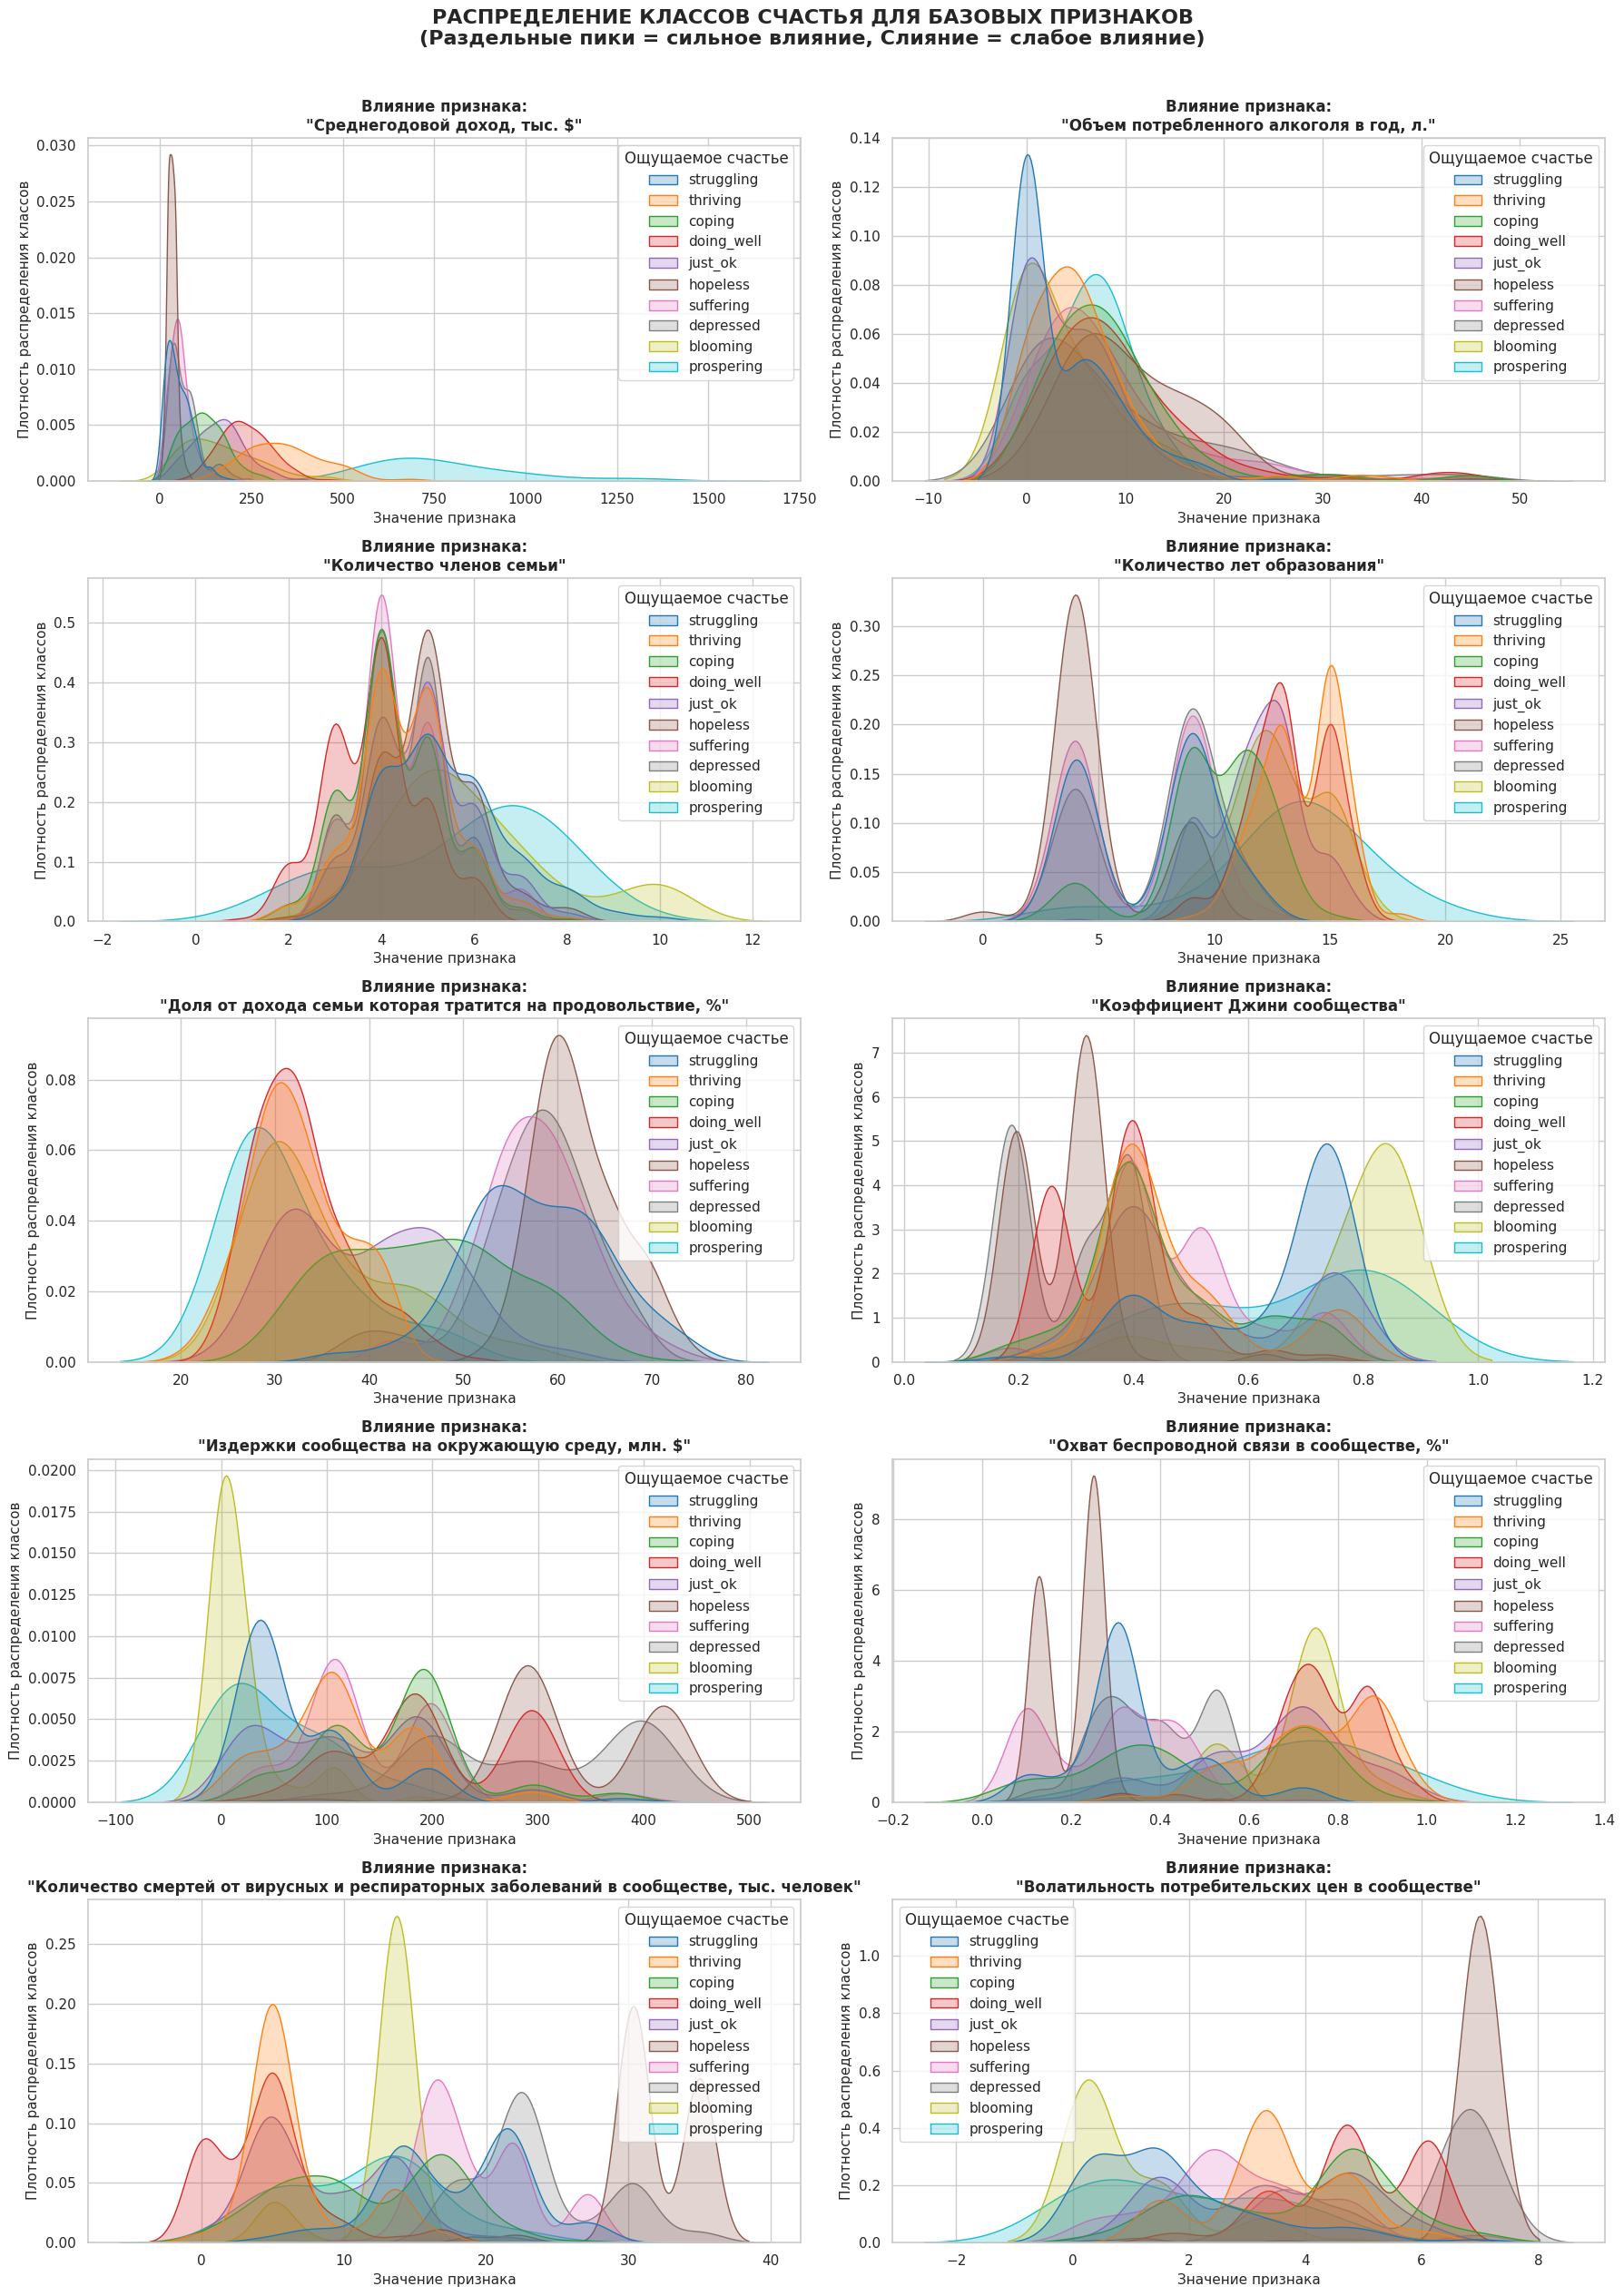

3. Отрисовка плотностей распределения скрытых состояний по классам Счастья...


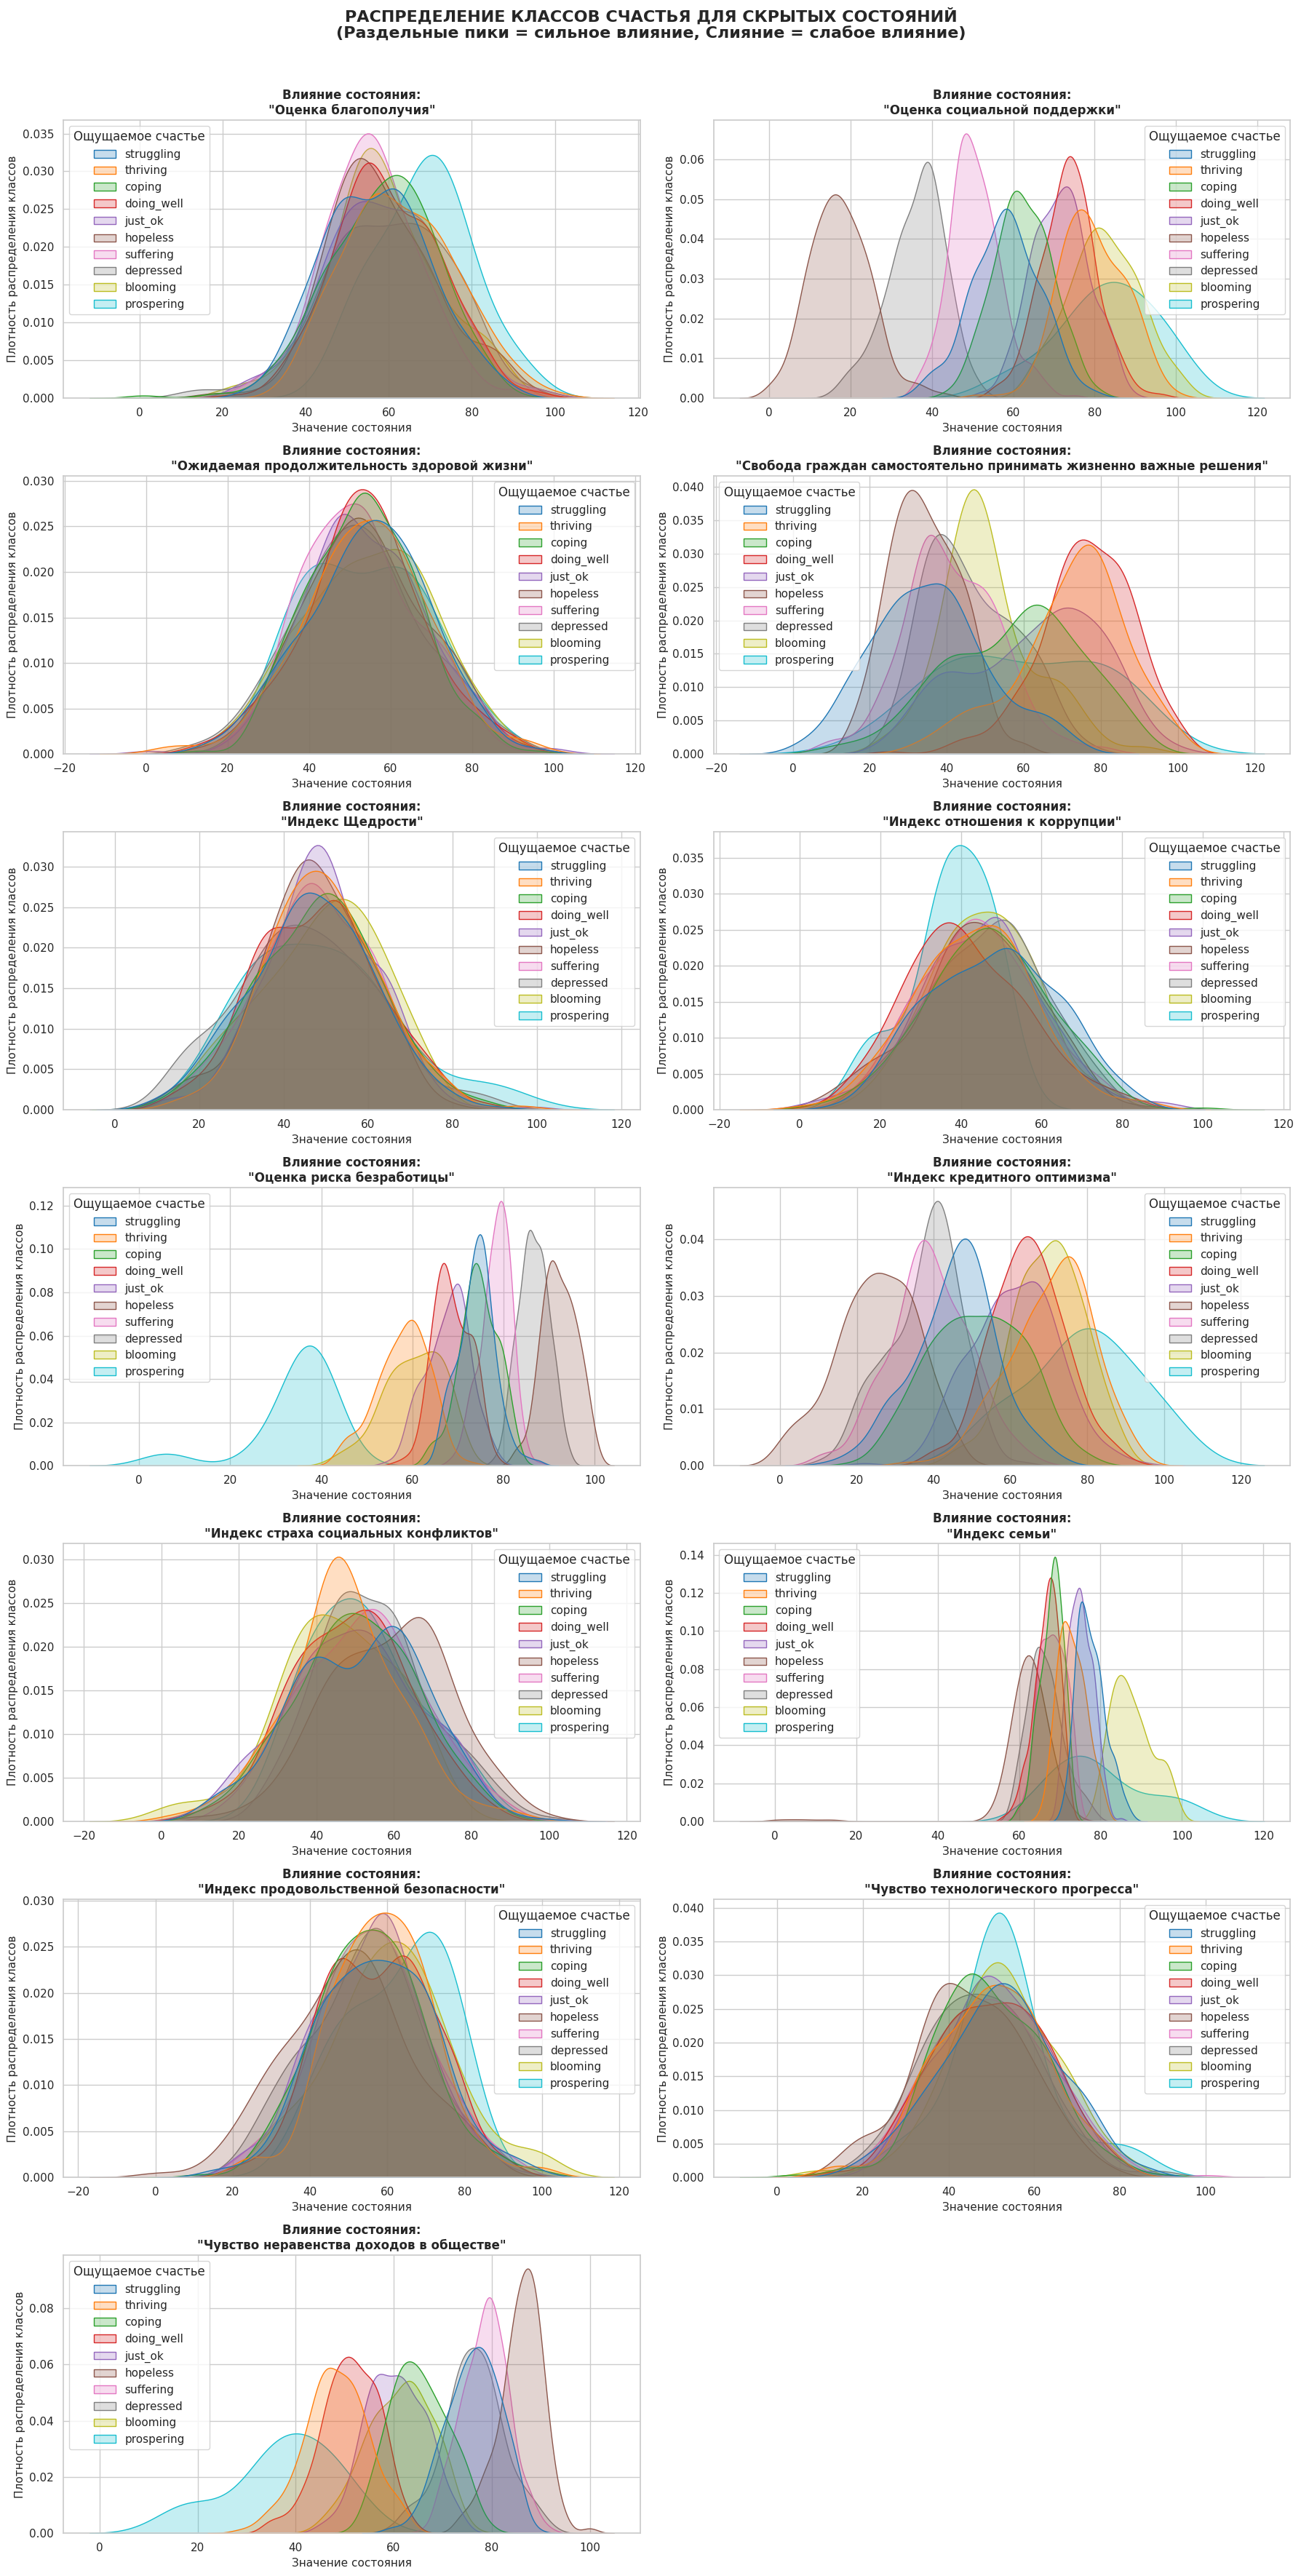

4. Отрисовка пространственных проекций (Кластеры vs Облака)...


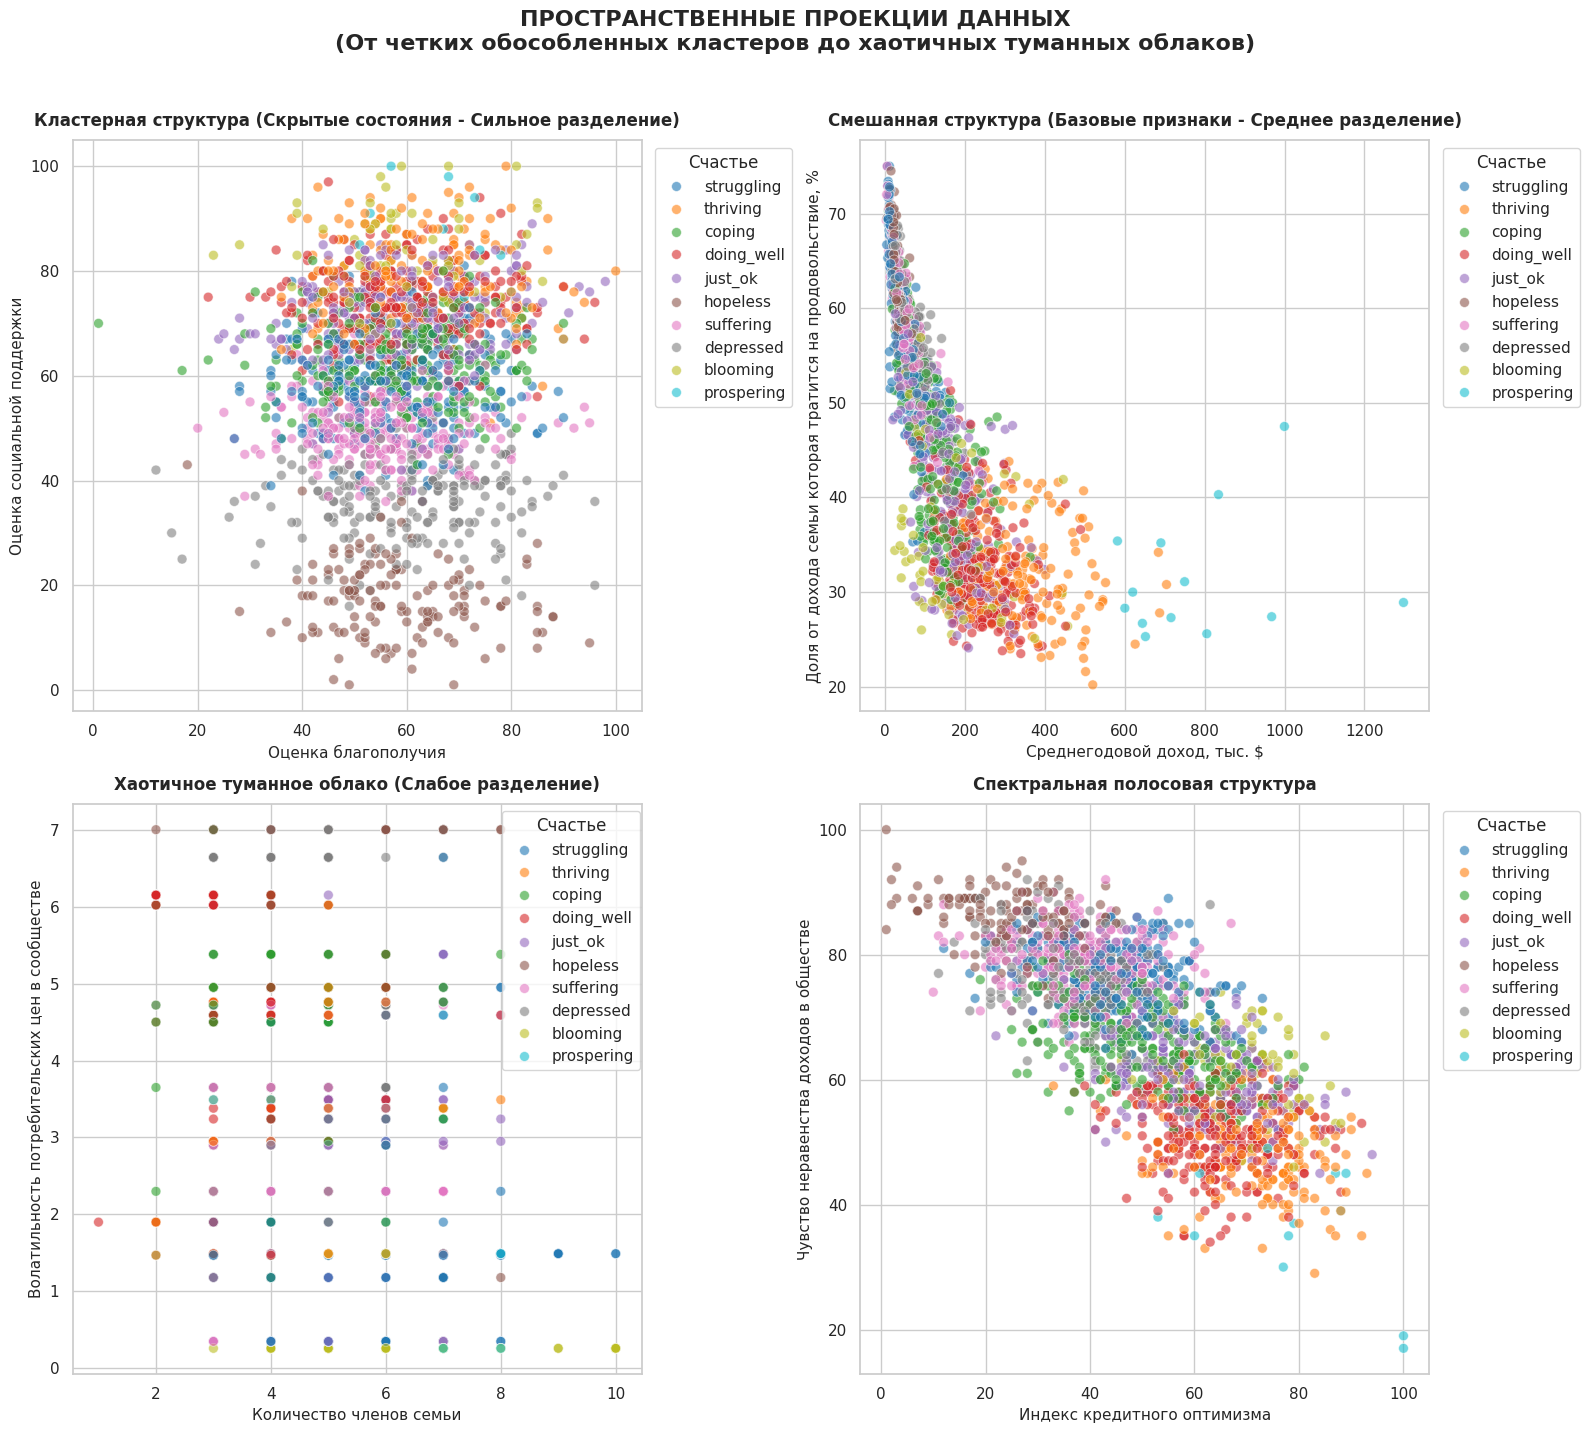

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

# Установим красивый стиль для отчета
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12})

# =====================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# =====================================================================
target = 'Ощущаемое счастье'
features = [
    'Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.',
    'Количество членов семьи', 'Количество лет образования',
    'Доля от дохода семьи которая тратится на продовольствие, %',
    'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $',
    'Охват беспроводной связи в сообществе, %',
    'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек',
    'Волатильность потребительских цен в сообществе'
]

hidden_states_all = [
    'Оценка благополучия', 'Оценка социальной поддержки',
    'Ожидаемая продолжительность здоровой жизни',
    'Свобода граждан самостоятельно принимать жизненно важные решения',
    'Индекс Щедрости', 'Индекс отношения к коррупции',
    'Оценка риска безработицы', 'Индекс кредитного оптимизма',
    'Индекс страха социальных конфликтов', 'Индекс семьи',
    'Индекс продовольственной безопасности', 'Чувство технологического прогресса',
    'Чувство неравенства доходов в обществе'
]

# Функция очистки
def clean_labels(series):
    return (series.astype(str)
            .str.strip().str.lower()
            .str.replace('strugglng', 'struggling')
            .str.replace('just ok', 'just_ok')
            .str.replace('doing well', 'doing_well'))

# Загружаем оригинал, чтобы посмотреть на чистые зависимости
df_anal = pd.read_excel('/content/Вар_47_Б24-215_Новиков_Лаба2_студент-3.xlsx')
df_anal[target] = clean_labels(df_anal[target])

# Убираем неизвестные для чистоты анализа
df_anal = df_anal[~df_anal[target].isin(['неизвестно', 'nan', 'none'])]

# Заполняем пропуски для корректной работы графиков
for col in features + hidden_states_all:
    df_anal[col] = df_anal[col].fillna(df_anal[col].mean())

# =====================================================================
# ГРАФИК 1: ПОСТРОЕНИЕ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ
# =====================================================================
print("1. Отрисовка корреляционной матрицы...")
combined_cols = features + hidden_states_all
corr_matrix = df_anal[combined_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title('КОРРЕЛЯЦИОННАЯ МАТРИЦА (Причины + Скрытые состояния)', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =====================================================================
# ГРАФИК 2: РАСПРЕДЕЛЕНИЯ КЛАССОВ ДЛЯ ВСЕХ БАЗОВЫХ ПРИЗНАКОВ (Пики vs Смешивание)
# =====================================================================
print("2. Отрисовка плотностей распределения базовых признаков по классам Счастья...")
cols = 2
rows_f = math.ceil(len(features) / cols)

plt.figure(figsize=(18, 5 * rows_f))
for i, f in enumerate(features, 1):
    plt.subplot(rows_f, cols, i)
    # common_norm=False позволяет видеть пики каждого класса независимо от объема выборки
    sns.kdeplot(data=df_anal, x=f, hue=target, fill=True, common_norm=False, alpha=0.25, palette='tab10')
    plt.title(f'Влияние признака:\n"{f}"', fontsize=12, fontweight='bold')
    plt.xlabel('Значение признака')
    plt.ylabel('Плотность распределения классов')
plt.suptitle('РАСПРЕДЕЛЕНИЕ КЛАССОВ СЧАСТЬЯ ДЛЯ БАЗОВЫХ ПРИЗНАКОВ\n(Раздельные пики = сильное влияние, Слияние = слабое влияние)', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# ГРАФИК 3: РАСПРЕДЕЛЕНИЯ КЛАССОВ ДЛЯ ВСЕХ СКРЫТЫХ СОСТОЯНИЙ (Пики vs Смешивание)
# =====================================================================
print("3. Отрисовка плотностей распределения скрытых состояний по классам Счастья...")
rows_hs = math.ceil(len(hidden_states_all) / cols)

plt.figure(figsize=(18, 5 * rows_hs))
for i, hs in enumerate(hidden_states_all, 1):
    plt.subplot(rows_hs, cols, i)
    sns.kdeplot(data=df_anal, x=hs, hue=target, fill=True, common_norm=False, alpha=0.25, palette='tab10')
    plt.title(f'Влияние состояния:\n"{hs}"', fontsize=12, fontweight='bold')
    plt.xlabel('Значение состояния')
    plt.ylabel('Плотность распределения классов')
plt.suptitle('РАСПРЕДЕЛЕНИЕ КЛАССОВ СЧАСТЬЯ ДЛЯ СКРЫТЫХ СОСТОЯНИЙ\n(Раздельные пики = сильное влияние, Слияние = слабое влияние)', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# ГРАФИК 4: ТУМАННЫЕ КУЧКИ VS КОМПАКТНЫЕ КЛАСТЕРЫ (2D Scatter Plots)
# =====================================================================
print("4. Отрисовка пространственных проекций (Кластеры vs Облака)...")
# Мы выберем 4 характерные пары, чтобы наглядно показать разницу
pairs_to_plot = [
    # 1. Сильно разделенные (кластеры)
    ('Оценка благополучия', 'Оценка социальной поддержки', 'Кластерная структура (Скрытые состояния - Сильное разделение)'),
    # 2. Средне разделенные
    ('Среднегодовой доход, тыс. $', 'Доля от дохода семьи которая тратится на продовольствие, %', 'Смешанная структура (Базовые признаки - Среднее разделение)'),
    # 3. Слабо разделенные (туманное облако)
    ('Количество членов семьи', 'Волатильность потребительских цен в сообществе', 'Хаотичное туманное облако (Слабое разделение)'),
    # 4. Интересная ординальная зависимость
    ('Индекс кредитного оптимизма', 'Чувство неравенства доходов в обществе', 'Спектральная полосовая структура')
]

plt.figure(figsize=(16, 14))
for i, (x_col, y_col, title_text) in enumerate(pairs_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(
        data=df_anal,
        x=x_col,
        y=y_col,
        hue=target,
        palette='tab10',
        alpha=0.6,
        s=50,
        edgecolor='w'
    )
    plt.title(title_text, fontsize=12, fontweight='bold', pad=10)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title='Счастье', bbox_to_anchor=(1.01, 1), loc='upper left' if i%2==0 else 'best')
plt.suptitle('ПРОСТРАНСТВЕННЫЕ ПРОЕКЦИИ ДАННЫХ\n(От четких обособленных кластеров до хаотичных туманных облаков)', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Отрисовка влияния всех 10 признаков на состояния: ['Оценка социальной поддержки', 'Оценка риска безработицы', 'Индекс семьи', 'Индекс отношения к коррупции', 'Чувство неравенства доходов в обществе']...


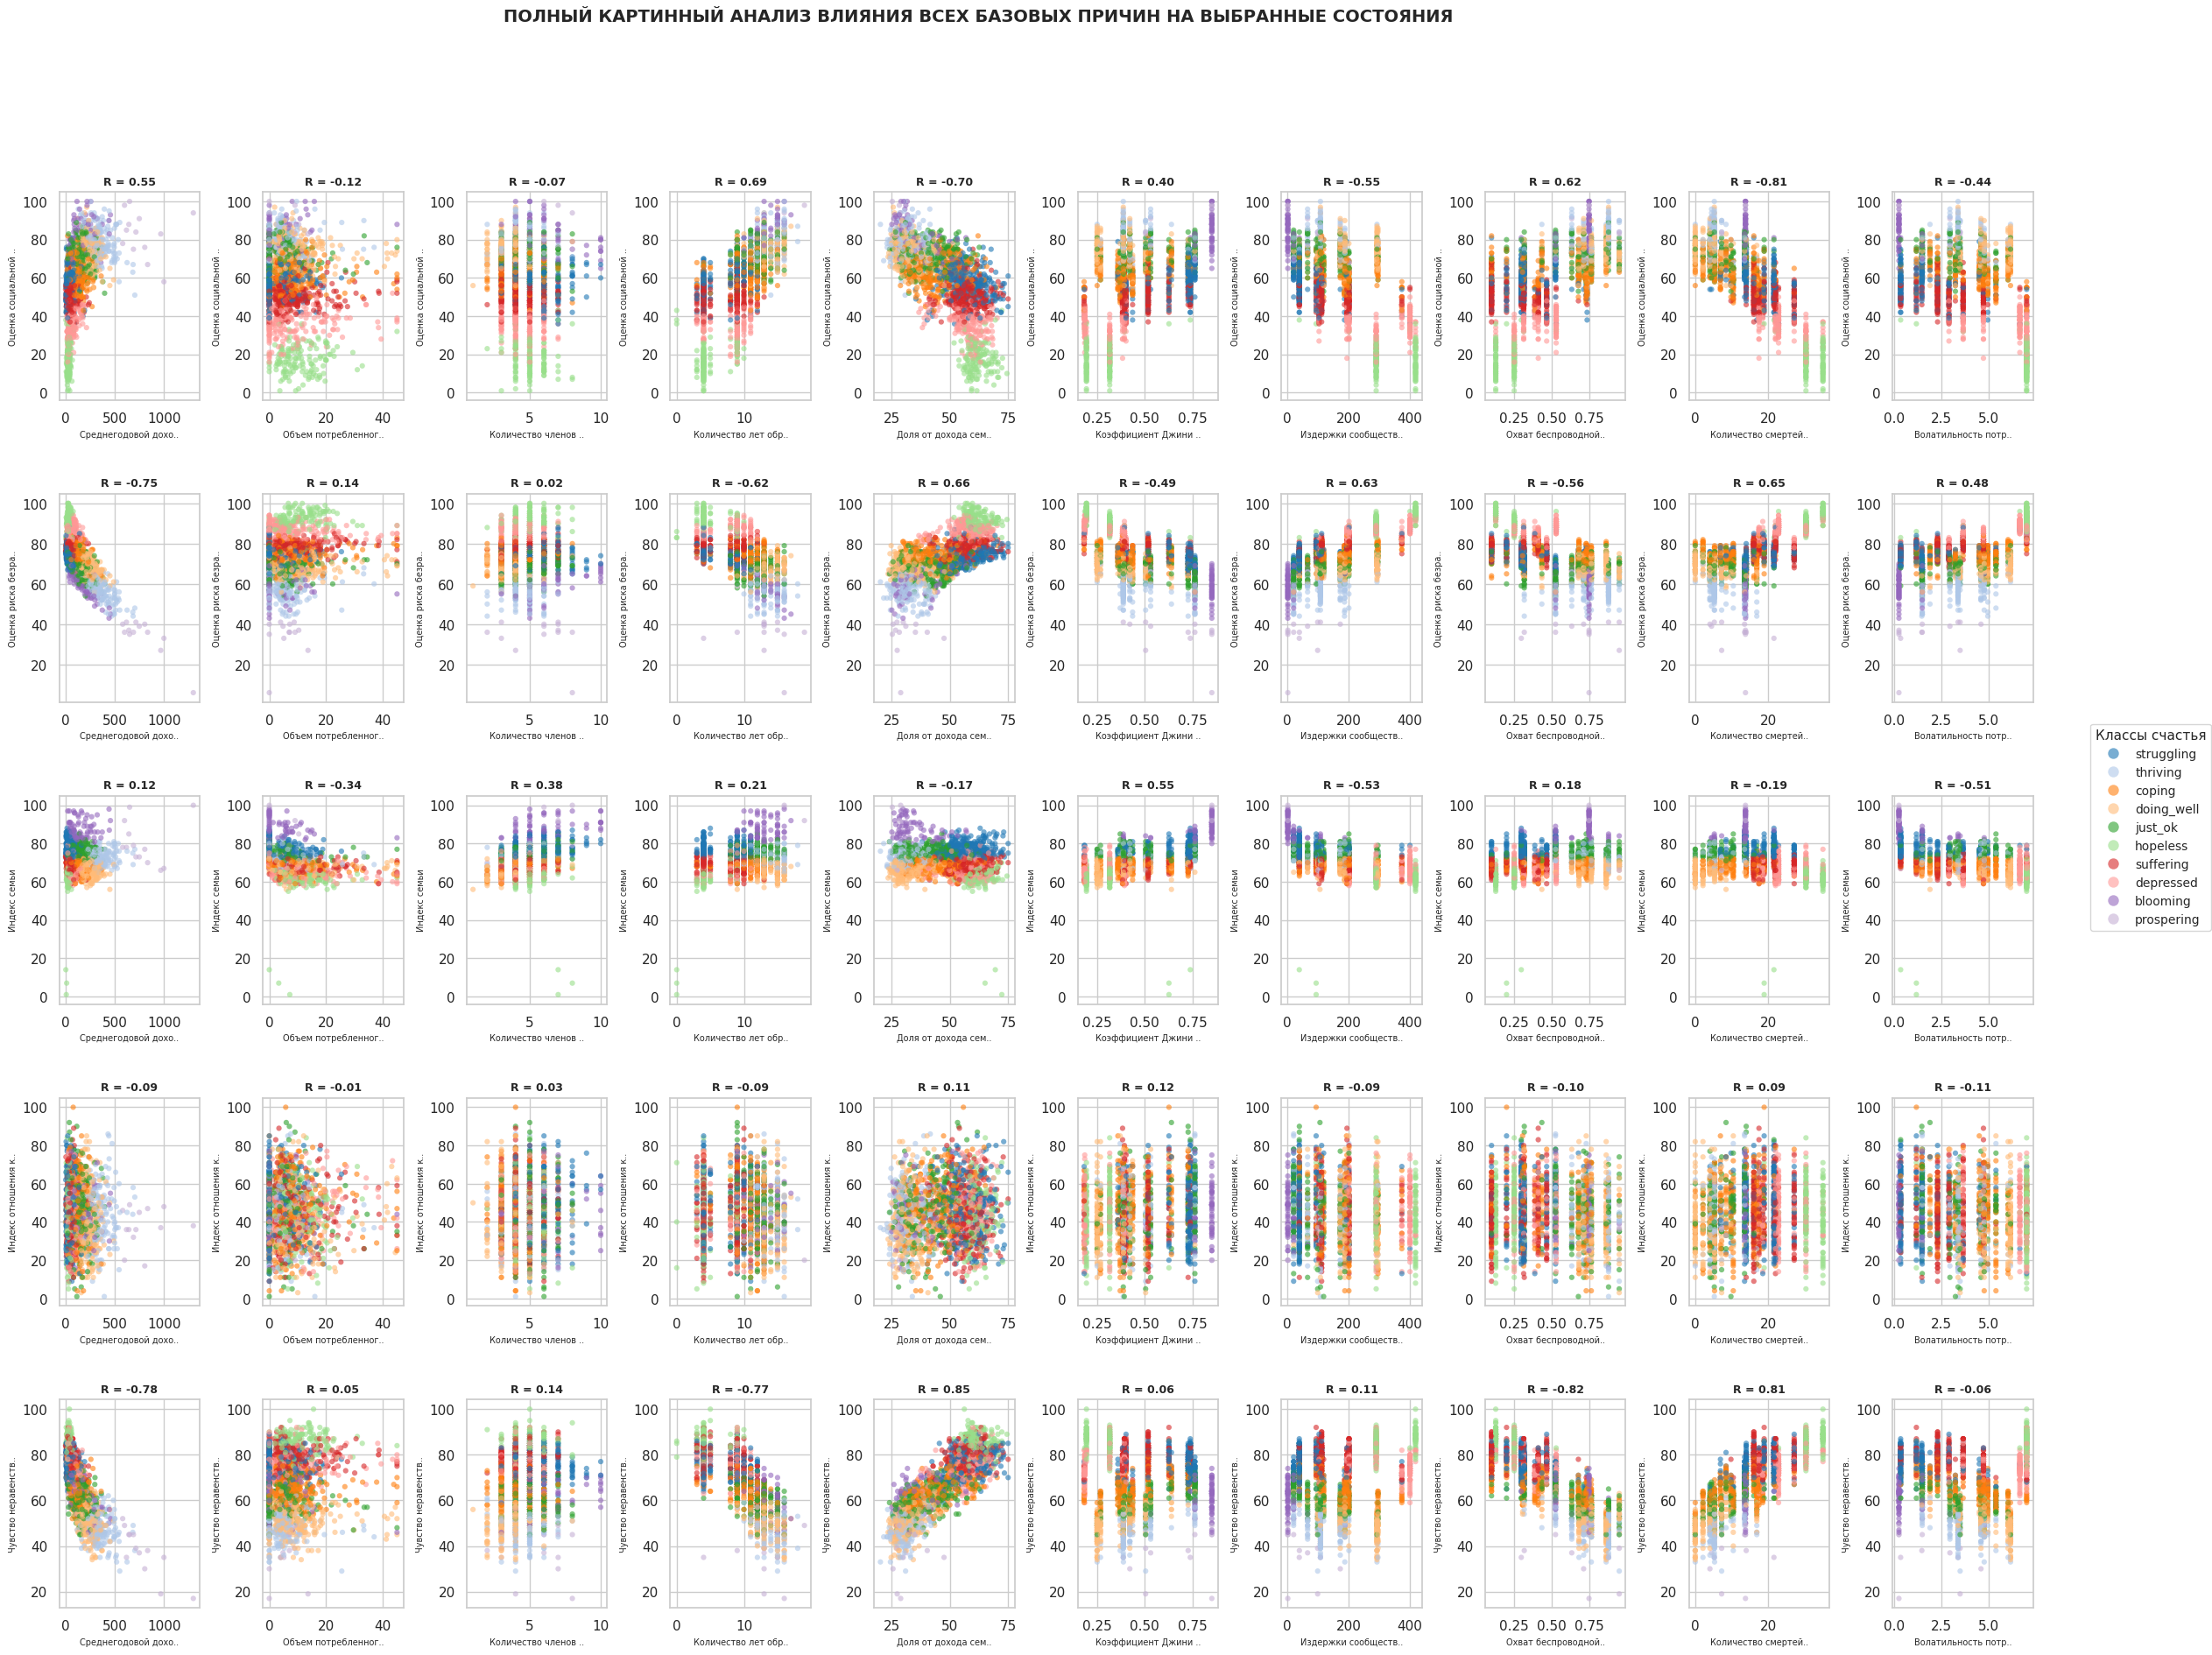

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для сверхшироких графиков (10 колонок!)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 9
})

# =====================================================================
# ПОДГОТОВКА ДАННЫХ (Загрузка оригинала для анализа)
# =====================================================================
target = 'Ощущаемое счастье'
features = [
    'Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.',
    'Количество членов семьи', 'Количество лет образования',
    'Доля от дохода семьи которая тратится на продовольствие, %',
    'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $',
    'Охват беспроводной связи в сообществе, %',
    'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек',
    'Волатильность потребительских цен в сообществе'
]

# Список всех доступных скрытых состояний (для удобства копирования)
all_available_states = [
    'Оценка благополучия', 'Оценка социальной поддержки',
    'Ожидаемая продолжительность здоровой жизни',
    'Свобода граждан самостоятельно принимать жизненно важные решения',
    'Индекс Щедрости', 'Индекс отношения к коррупции',
    'Оценка риска безработицы', 'Индекс кредитного оптимизма',
    'Индекс страха социальных конфликтов', 'Индекс семьи',
    'Индекс продовольственной безопасности', 'Чувство технологического прогресса',
    'Чувство неравенства доходов в обществе'
]

def clean_labels(series):
    return (series.astype(str)
            .str.strip().str.lower()
            .str.replace('strugglng', 'struggling')
            .str.replace('just ok', 'just_ok')
            .str.replace('doing well', 'doing_well'))

# Загрузка
df_pairs = pd.read_excel('data.xlsx')
df_pairs[target] = clean_labels(df_pairs[target])
df_pairs = df_pairs[~df_pairs[target].isin(['неизвестно', 'nan', 'none'])]

# Заполнение пропусков
for col in features + all_available_states:
    df_pairs[col] = df_pairs[col].fillna(df_pairs[col].mean())


# =====================================================================
# МАСШТАБИРУЕМАЯ ФУНКЦИЯ ПОСТРОЕНИЯ ГРАФИКОВ
# =====================================================================
def plot_state_influence(states_to_inspect):
    """
    Строит сетку графиков: для каждого состояния из списка показывает
    влияние всех 10 базовых причин.
    """
    num_states = len(states_to_inspect)

    # Создаем сетку: строк столько, сколько состояний; колонок всегда 10 (все причины)
    fig, axes = plt.subplots(num_states, 10, figsize=(28, 4.2 * num_states))

    # Принудительно делаем axes двумерным массивом (даже если передано всего 1 состояние)
    axes = np.atleast_2d(axes)

    palette_colors = sns.color_palette("tab20", len(df_pairs[target].unique()))
    handles, labels = [], []

    print(f"Отрисовка влияния всех 10 признаков на состояния: {states_to_inspect}...")

    for row_idx, hs in enumerate(states_to_inspect):
        for col_idx, cause in enumerate(features):
            ax = axes[row_idx, col_idx]

            # Строим Scatter Plot
            sns.scatterplot(
                data=df_pairs,
                x=cause,
                y=hs,
                hue=target,
                palette=palette_colors,
                alpha=0.6,
                s=20,
                edgecolor='none',
                ax=ax,
                legend=(row_idx == 0 and col_idx == 0) # Легенда только для самого первого графика
            )

            if row_idx == 0 and col_idx == 0:
                handles, labels = ax.get_legend_handles_labels()

            # Считаем корреляцию Пирсона локально для заголовка
            r_val = df_pairs[cause].corr(df_pairs[hs])

            # Укорачиваем длинные названия
            short_cause = cause[:18] + '..' if len(cause) > 18 else cause
            short_hs = hs[:18] + '..' if len(hs) > 18 else hs

            ax.set_title(f"R = {r_val:.2f}", fontsize=9, fontweight='bold')
            ax.set_xlabel(short_cause, fontsize=7)
            ax.set_ylabel(short_hs, fontsize=7)

            # Удаляем встроенные легенды
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    # Добавляем общую легенду справа
    fig.legend(
        handles,
        labels,
        title="Классы счастья",
        loc="center right",
        borderaxespad=0.1,
        fontsize=10,
        title_fontsize=11,
        markerscale=2.0
    )

    # Оптимизируем положение графиков
    plt.subplots_adjust(right=0.93, hspace=0.45, wspace=0.45)
    plt.suptitle('ПОЛНЫЙ КАРТИННЫЙ АНАЛИЗ ВЛИЯНИЯ ВСЕХ БАЗОВЫХ ПРИЧИН НА ВЫБРАННЫЕ СОСТОЯНИЯ', y=0.98, fontsize=14, fontweight='bold')
    plt.show()

# =====================================================================
# ПРИМЕР ВЫЗОВА ФУНКЦИИ
# =====================================================================
# Просто напиши в этот список любые состояния, которые хочешь исследовать!
my_test_list = [
    'Оценка социальной поддержки',
    'Оценка риска безработицы',
    'Индекс семьи',
    'Индекс отношения к коррупции',
    'Чувство неравенства доходов в обществе'
]

plot_state_influence(my_test_list)

In [51]:
custom_mapping = {
    'Индекс отношения к коррпуции': [
        'Количество членов семьи',
        'Количество лет образования',
        'Доля от дохода семьи которая тратится на продовольствие, %'
    ],
    'Индекс семьи': [
        'Количество лет образования',
        'Доля от дохода семьи которая тратится на продовольствие, %'
        'Охват беспроводной связи в сообществе, %'],
    'Оценка риска безработицы':[
        'Количество членов семьи',
        'Количество лет образования',
        'Доля от дохода семьи которая тратится на продовольствие, %'
    ]}



In [52]:
# %%
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
from sklearn.feature_selection import f_classif, f_regression

# =====================================================================
# БЛОК 3.5: АВТОМАТИЧЕСКИЙ ОТБОР ПРИЗНАКОВ И СОСТОЯНИЙ (STATISTICAL SELECTION)
# =====================================================================
print("\nЗАПУСК СТАТИСТИЧЕСКОГО ОТБОРА ПРИЗНАКОВ...\n")

# Устанавливаем пороги (гиперпараметры отбора)
P_VALUE_THRESH = 0.05    # Максимальный уровень значимости (5%)
MIN_CORR_TARGET = 0.15   # Минимальная корреляция состояния с таргетом
MIN_CORR_FEATURE = 0.10  # Минимальная корреляция базового признака с состоянием
MAX_FEATURES_PER_STATE = 5 # Максимум базовых признаков для одного состояния

# Убедимся, что таргет переведен в числа для корреляции Спирмена
if 'target_ordinal' not in train_df.columns:
    train_df['target_ordinal'] = train_df[target].map(ordinal_mapping)

# ---------------------------------------------------------
# ЭТАП 1: Отбор лучших скрытых состояний для предсказания Счастья
# ---------------------------------------------------------
print("ЭТАП 1: Анализ 'Скрытые состояния -> Счастье'")
selected_states = []

# Удаляем строки с пропусками в скрытых состояниях И в целевой переменной
clean_mask = train_df[all_available_states].notna().all(axis=1) & train_df['target_ordinal'].notna()
X_clean = train_df.loc[clean_mask, all_available_states]
y_clean = train_df.loc[clean_mask, 'target_ordinal']

print(f"Всего строк в train_df: {len(train_df)}")
print(f"Строк без пропусков: {len(X_clean)}")

if len(X_clean) > 0:
    # f_classif (ANOVA) проверяет, отличаются ли средние значения состояний в разных классах счастья
    f_stats_target, p_vals_target = f_classif(X_clean, y_clean)

    for idx, hs in enumerate(all_available_states):
        # Корреляция Спирмена (учитывает порядковость таргета)
        rho, _ = spearmanr(X_clean[hs], y_clean)
        p_val = p_vals_target[idx]

        # Отбираем, если связь статистически значима и достаточно сильна
        if p_val < P_VALUE_THRESH and abs(rho) >= MIN_CORR_TARGET:
            selected_states.append((hs, abs(rho), p_val))

    # Сортируем состояния по силе корреляции (от сильной к слабой)
    selected_states.sort(key=lambda x: x[1], reverse=True)
    # Оставим, например, топ-5 самых сильных состояний, чтобы не переобучить модель
    top_states = [state[0] for state in selected_states[:5]]

    print(f"Отобрано состояний: {len(top_states)}")
    for state, rho, p_val in selected_states[:5]:
        print(f"  - {state[:30]}... | Спирмен: {rho:.3f}, p-value: {p_val:.1e}")
else:
    print("ОШИБКА: Нет данных без пропусков для анализа!")
    top_states = []

# ---------------------------------------------------------
# ЭТАП 2: Подбор базовых причин для каждого отобранного состояния
# ---------------------------------------------------------
print("\nЭТАП 2: Анализ 'Базовые причины -> Скрытые состояния'")
auto_mapping = {}

if len(top_states) > 0:
    # Удаляем строки с пропусками для этапа 2
    clean_mask_hs = train_df[top_states + features].notna().all(axis=1)
    train_clean_hs = train_df.loc[clean_mask_hs]

    print(f"Строк без пропусков для этапа 2: {len(train_clean_hs)} из {len(train_df)}")

    for hs in top_states:
        # f_regression проверяет наличие линейной зависимости между признаком и таргетом(состоянием)
        f_stats_hs, p_vals_hs = f_regression(train_clean_hs[features], train_clean_hs[hs])

        valid_features = []
        for idx, feature in enumerate(features):
            # Корреляция Пирсона (для двух непрерывных переменных)
            r, _ = pearsonr(train_clean_hs[feature], train_clean_hs[hs])
            p_val = p_vals_hs[idx]

            if p_val < P_VALUE_THRESH and abs(r) >= MIN_CORR_FEATURE:
                valid_features.append((feature, abs(r)))

        # Сортируем фичи по убыванию корреляции и берем топ N
        valid_features.sort(key=lambda x: x[1], reverse=True)
        best_features_for_hs = [f[0] for f in valid_features[:MAX_FEATURES_PER_STATE]]

        if best_features_for_hs: # Если нашлись хорошие фичи
            auto_mapping[hs] = best_features_for_hs

# Вывод получившегося словаря
print("\nИТОГОВЫЙ СГЕНЕРИРОВАННЫЙ МАППИНГ (auto_mapping):")
if auto_mapping:
    for hs, feats in auto_mapping.items():
        print(f"[{hs}]:")
        for f in feats:
            print(f"    <- {f}")
else:
    print("Не найдено значимых связей! Возможно, пороги слишком строгие или данные содержат пропуски.")

# ЗАМЕНЯЕМ ВАШ РУЧНОЙ СЛОВАРЬ НА АВТОМАТИЧЕСКИЙ!
custom_mapping = auto_mapping


ЗАПУСК СТАТИСТИЧЕСКОГО ОТБОРА ПРИЗНАКОВ...

ЭТАП 1: Анализ 'Скрытые состояния -> Счастье'
Всего строк в train_df: 2500
Строк без пропусков: 1134
Отобрано состояний: 5
  - Оценка социальной поддержки... | Спирмен: 0.762, p-value: 0.0e+00
  - Оценка риска безработицы... | Спирмен: 0.745, p-value: 0.0e+00
  - Чувство неравенства доходов в ... | Спирмен: 0.683, p-value: 0.0e+00
  - Индекс кредитного оптимизма... | Спирмен: 0.635, p-value: 3.5e-260
  - Индекс семьи... | Спирмен: 0.472, p-value: 2.1e-230

ЭТАП 2: Анализ 'Базовые причины -> Скрытые состояния'
Строк без пропусков для этапа 2: 1900 из 2500

ИТОГОВЫЙ СГЕНЕРИРОВАННЫЙ МАППИНГ (auto_mapping):
[Оценка социальной поддержки]:
    <- Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
    <- Доля от дохода семьи которая тратится на продовольствие, %
    <- Количество лет образования
    <- Охват беспроводной связи в сообществе, %
    <- Издержки сообщества на окружающую среду, млн. $
[Оценка риска без

БЛОК 1-3: Подготовка данных...

Запуск строгой 5-Fold Кросс-Валидации...
  * Фолд 1 успешно пройден!
  * Фолд 2 успешно пройден!
  * Фолд 3 успешно пройден!
  * Фолд 4 успешно пройден!
  * Фолд 5 успешно пройден!

=== РЕЗУЛЬТАТЫ 5-FOLD КРОСС-ВАЛИДАЦИИ ===
Формула микроточности: 1263 / (1263 + 637)
ЧЕСТНАЯ СРЕДНЯЯ ТОЧНОСТЬ (CV Micro-Precision): 0.6647


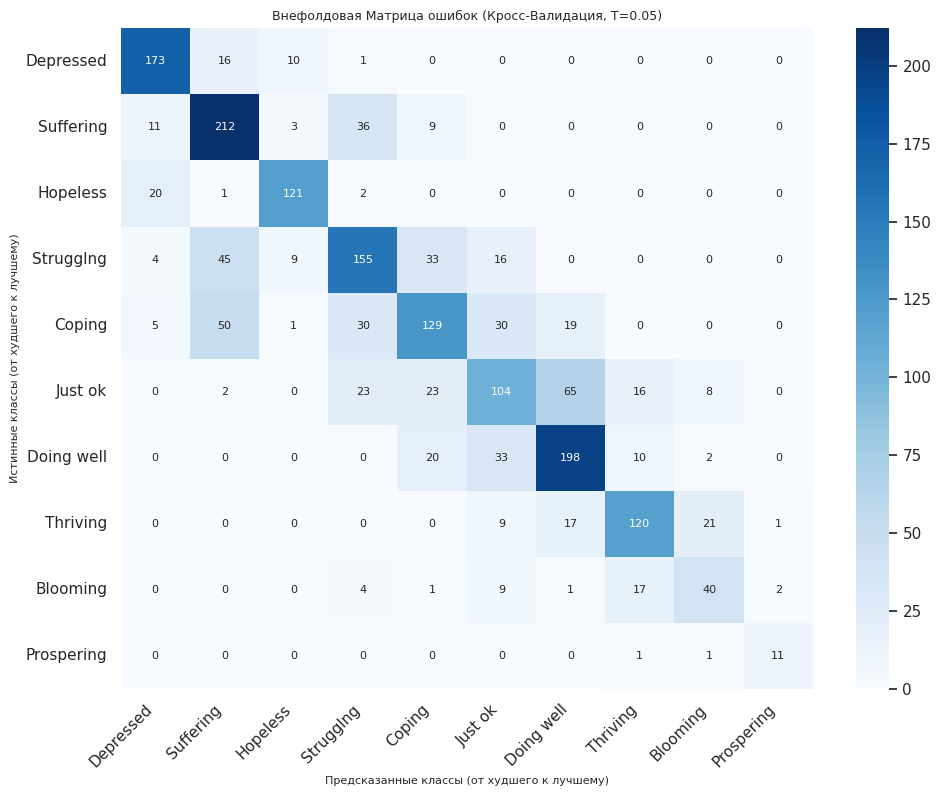


Финальное обучение на 100% данных и экспорт...
Файл 'predicted_unknown_happiness.xlsx' успешно отформатирован и сохранен для сдачи!


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# ТЕМПЕРАТУРА ОБОСТРЕНИЯ (Регулирует разброс предсказаний)
temperature = 0.05

target = 'Ощущаемое счастье'

ordered_classes = [
    'depressed', 'suffering', 'hopeless', 'struggling',
    'coping', 'just_ok', 'doing_well', 'thriving',
    'blooming', 'prospering'
]
ordinal_mapping = {label: idx for idx, label in enumerate(ordered_classes)}

output_formatting = {
    'depressed': 'Depressed',
    'suffering': 'Suffering',
    'hopeless': 'Hopeless',
    'struggling': 'Strugglng',  # Возвращаем фирменную опечатку Strugglng!
    'coping': 'Coping',
    'just_ok': 'Just ok',       # Без нижнего подчеркивания
    'doing_well': 'Doing well', # Без нижнего подчеркивания
    'thriving': 'Thriving',
    'blooming': 'Blooming',
    'prospering': 'Prospering'
}

features = list(set([feat for feats in custom_mapping.values() for feat in feats]))
selected_states = list(custom_mapping.keys())

def clean_labels(series):
    return (series.astype(str)
            .str.strip().str.lower()
            .str.replace('strugglng', 'struggling')
            .str.replace('just ok', 'just_ok')
            .str.replace('doing well', 'doing_well'))

# =====================================================================
# ПОДГОТОВКА ДАННЫХ
# =====================================================================
print("БЛОК 1-3: Подготовка данных...")
df = pd.read_excel('data.xlsx')
df[target] = clean_labels(df[target])

for col in features + selected_states:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

test_df = df[(df[target] == 'неизвестно') | (df[target] == 'nan')].copy()
train_df = df[(df[target] != 'неизвестно') & (df[target] != 'nan')].copy()

train_df['target_ordinal'] = train_df[target].map(ordinal_mapping)
train_df = train_df.reset_index(drop=True)

# =====================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =====================================================================
def generate_interaction_features(df_input, mapping):
    feature_matrices = {}
    for hs, causes in mapping.items():
        base_data = df_input[causes].copy()
        interaction_data = pd.DataFrame(index=df_input.index)
        if len(causes) > 1:
            for i in range(len(causes)):
                for j in range(i + 1, len(causes)):
                    col_name = f"{causes[i]} x {causes[j]}"
                    interaction_data[col_name] = df_input[causes[i]] * df_input[causes[j]]
        combined = pd.concat([base_data, interaction_data], axis=1)
        feature_matrices[hs] = combined
    return feature_matrices

def predict_with_expected_rank(classifier, predicted_states_df, temp=1.0):
    probs = classifier.predict_proba(predicted_states_df)
    probs_sharpened = np.power(probs, 1.0 / temp)
    probs_sharpened = probs_sharpened / np.sum(probs_sharpened, axis=1, keepdims=True)
    ranks = np.arange(len(ordered_classes))
    expected_ranks = np.dot(probs_sharpened, ranks)
    return np.clip(np.round(expected_ranks), 0, len(ordered_classes) - 1).astype(int)

# =====================================================================
# СТРОГАЯ КРОСС-ВАЛИДАЦИЯ (БЕЗ УТЕЧКИ ДАННЫХ)
# =====================================================================
print("\nЗапуск строгой 5-Fold Кросс-Валидации...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Сюда мы будем собирать внефолдовые (out-of-fold) предсказания модели
oof_predictions = np.zeros(len(train_df))

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['target_ordinal']), 1):
    # Разделяем фолды
    fold_train = train_df.iloc[train_idx].copy()
    fold_val = train_df.iloc[val_idx].copy()

    # 1. Масштабируем признаки строго ВНУТРИ фолда (борьба с утечкой данных!)
    fold_scaler = StandardScaler()
    X_fold_train_scaled = pd.DataFrame(fold_scaler.fit_transform(fold_train[features]), columns=features, index=fold_train.index)
    X_fold_val_scaled = pd.DataFrame(fold_scaler.transform(fold_val[features]), columns=features, index=fold_val.index)

    # 2. Генерируем синергетические взаимодействия
    train_interactions = generate_interaction_features(X_fold_train_scaled, custom_mapping)
    val_interactions = generate_interaction_features(X_fold_val_scaled, custom_mapping)

    # 3. Обучаем регрессии 1-го уровня строго на обучающем фолде
    fold_models_hs = {}
    fold_train_predicted_states = pd.DataFrame(index=fold_train.index)
    fold_val_predicted_states = pd.DataFrame(index=fold_val.index)

    for hs, X_train_hs in train_interactions.items():
        lr = Ridge(alpha=5.0, random_state=42)
        lr.fit(X_train_hs, fold_train[hs])
        fold_models_hs[hs] = lr

        fold_train_predicted_states[hs] = lr.predict(X_train_hs)
        fold_val_predicted_states[hs] = lr.predict(val_interactions[hs])

    # 4. Обучаем классификатор счастья на обучающем фолде
    fold_classifier = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    fold_classifier.fit(fold_train_predicted_states, fold_train['target_ordinal'])

    # 5. Прогнозируем счастье для валидационного фолда через Soft-Argmax
    fold_val_preds = predict_with_expected_rank(fold_classifier, fold_val_predicted_states, temp=temperature)

    # Сохраняем предсказания
    oof_predictions[val_idx] = fold_val_preds
    print(f"  * Фолд {fold} успешно пройден!")

# =====================================================================
# РАСЧЕТ МЕТРИК КРОСС-ВАЛИДАЦИИ
# =====================================================================
K = len(ordered_classes)
y_true_oof = train_df['target_ordinal'].values

cm = confusion_matrix(y_true_oof, oof_predictions, labels=range(K))
sum_tp = np.sum(np.diag(cm))
sum_fp = np.sum(cm) - sum_tp
cv_micro_precision = sum_tp / (sum_tp + sum_fp)

print("\n=== РЕЗУЛЬТАТЫ 5-FOLD КРОСС-ВАЛИДАЦИИ ===")
print(f"Формула микроточности: {sum_tp} / ({sum_tp} + {sum_fp})")
print(f"ЧЕСТНАЯ СРЕДНЯЯ ТОЧНОСТЬ (CV Micro-Precision): {cv_micro_precision:.4f}")

# Отрисовка Кросс-Валидационной матрицы ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=[output_formatting[cls] for cls in ordered_classes],
            yticklabels=[output_formatting[cls] for cls in ordered_classes])
plt.title(f'Внефолдовая Матрица ошибок (Кросс-Валидация, T={temperature})')
plt.xlabel('Предсказанные классы (от худшего к лучшему)')
plt.ylabel('Истинные классы (от худшего к лучшему)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# =====================================================================
# ФИНАЛЬНОЕ ОБУЧЕНИЕ НА 100% ДАННЫХ ДЛЯ ПРОГНОЗА "НЕИЗВЕСТНО"
# =====================================================================
print("\nФинальное обучение на 100% данных и экспорт...")
final_scaler = StandardScaler()
X_train_scaled_raw = pd.DataFrame(final_scaler.fit_transform(train_df[features]), columns=features, index=train_df.index)
train_interaction_matrices = generate_interaction_features(X_train_scaled_raw, custom_mapping)

final_models_hs = {}
final_train_predicted_states = pd.DataFrame(index=train_df.index)

for hs, X_train_hs in train_interaction_matrices.items():
    lr = Ridge(alpha=5.0, random_state=42)
    lr.fit(X_train_hs, train_df[hs])
    final_models_hs[hs] = lr
    final_train_predicted_states[hs] = lr.predict(X_train_hs)

final_classifier = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
final_classifier.fit(final_train_predicted_states, train_df['target_ordinal'])

# Делаем предсказания для "Неизвестно"
X_test_scaled_raw = pd.DataFrame(final_scaler.transform(test_df[features]), columns=features, index=test_df.index)
test_interaction_matrices = generate_interaction_features(X_test_scaled_raw, custom_mapping)

test_predicted_states = pd.DataFrame(index=test_df.index)
for hs, X_test_hs in test_interaction_matrices.items():
    test_predicted_states[hs] = final_models_hs[hs].predict(X_test_hs)

test_preds_idx = predict_with_expected_rank(final_classifier, test_predicted_states, temp=temperature)

# ИСПРАВЛЕННЫЙ КЛЮЧЕВОЙ БЛОК:
# 1. Записываем строго в оригинальную колонку "Ощущаемое счастье" (вместо "Предсказанное...")
# 2. Форматируем строки в соответствии с образцом (с опечаткой Strugglng)
test_df['Ощущаемое счастье'] = [output_formatting[ordered_classes[idx]] for idx in test_preds_idx]

# Сохраняем итоговый Excel-файл
test_df.to_excel('predicted_unknown_happiness.xlsx', index=False)
print("Файл 'predicted_unknown_happiness.xlsx' успешно отформатирован и сохранен для сдачи!")